# Phase 1D: opponent-movement coupling diagnostics

Metrica Sample Game 1 only. This notebook asks one narrow question: **When an attacker visibly changes movement and a defender appears to go with them, can a corresponding defender adjustment be seen after accounting for collective defensive motion?**

Examples are manually fixed from raw soccer trajectories before velocity calculation. No cross-correlation, lag optimization, regression, similarity score, assignment inference, Track classification, relational weights, or automated example search is used.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
DATA=ROOT/'data'/'metrica_sample_game_1'
HOME_PATH=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'; AWAY_PATH=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
pd.DataFrame({'file':[HOME_PATH.name,AWAY_PATH.name],'sha256':[sha256(HOME_PATH),sha256(AWAY_PATH)]})

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...


In [2]:
def load_tracking(path,team):
    header=pd.read_csv(path,header=None,nrows=3); ps=[str(int(float(v))) for v in header.iloc[1,3:-2:2] if pd.notna(v)]
    cols=['Period','Frame','Time [s]']
    for p in ps: cols += [f'{team}_{p}_x',f'{team}_{p}_y']
    cols += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=cols),ps
home,home_players=load_tracking(HOME_PATH,'Home'); away,away_players=load_tracking(AWAY_PATH,'Away')
tracking={'Home':home,'Away':away}; players={'Home':home_players,'Away':away_players}; goalkeeper={'Home':'11','Away':'25'}
home.shape,away.shape

((145006, 33), (145006, 33))

## Selection record — frozen from raw trajectories

Two candidates were retained after manually viewing full-team raw paths, before calculating any velocities:

1. **Period 1, 590–598 s: Home Player2 / Away Player23.** Player23 makes a pronounced curved reversal; Player2 appears to make a corresponding curved adjustment. Other Home paths in the same window are heterogeneous, so the focal adjustment is not visually reducible to one uniform team translation.
2. **Period 1, 222.08–227.08 s: Home Player1 / Away Player18.** Player18 changes direction on a curved path into the 225.08 s tackle interaction; Player1 also curves and adjusts while surrounding Home trajectories differ. This may be closing/contact rather than sustained following, but it satisfies the visual selection criterion and is retained regardless of its later velocity diagnostic.

These are diagnostic examples, not assignments or Track labels. The raw views below precede all coupling calculations.

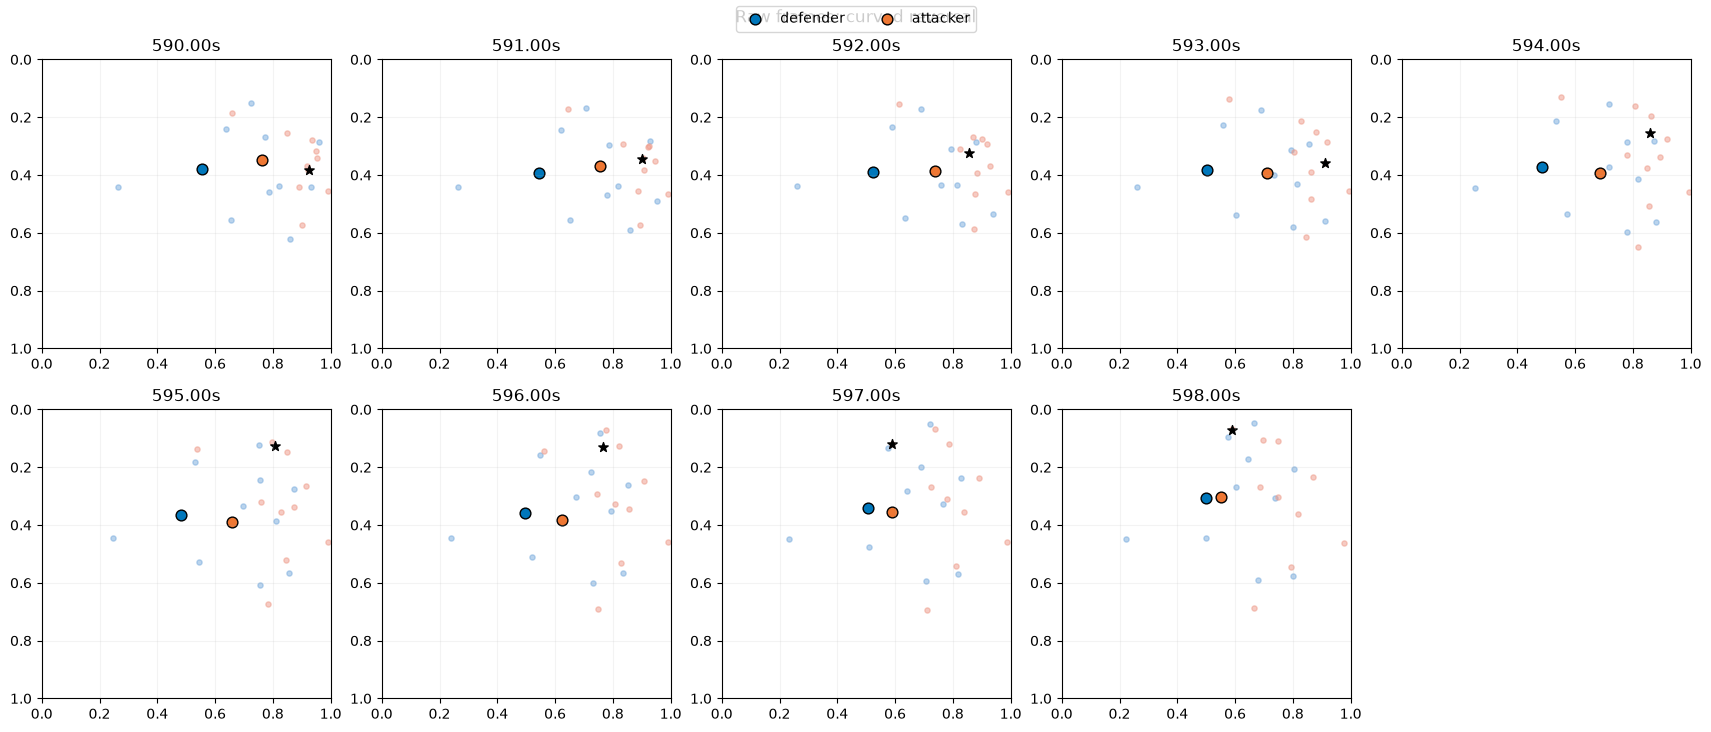

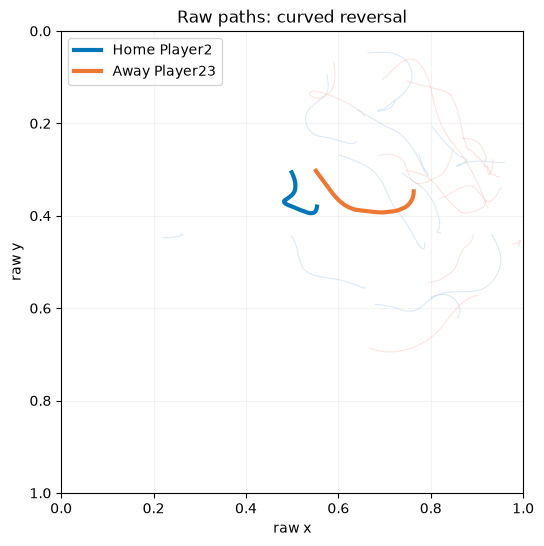

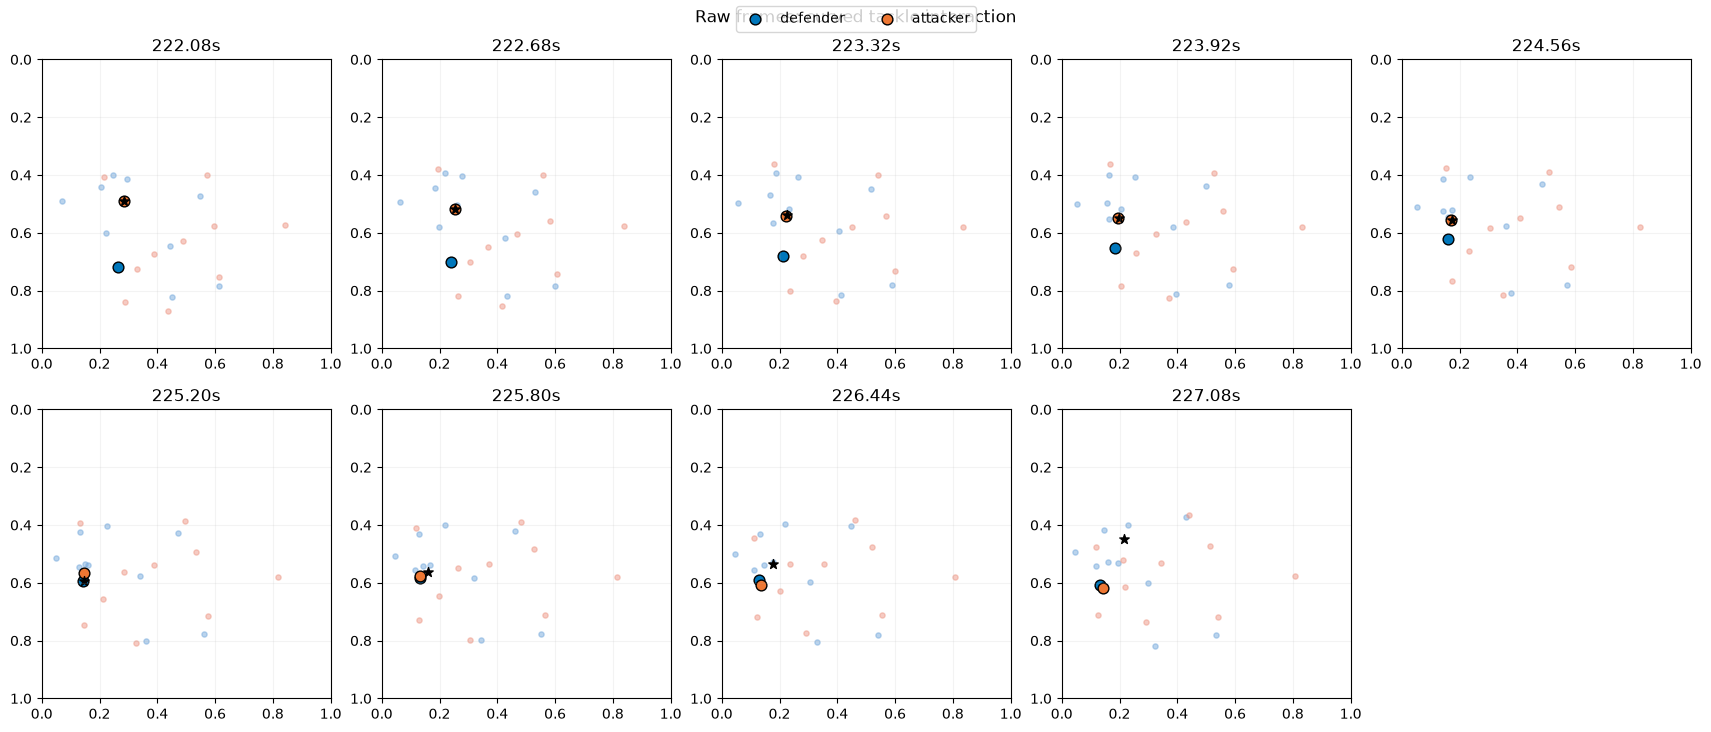

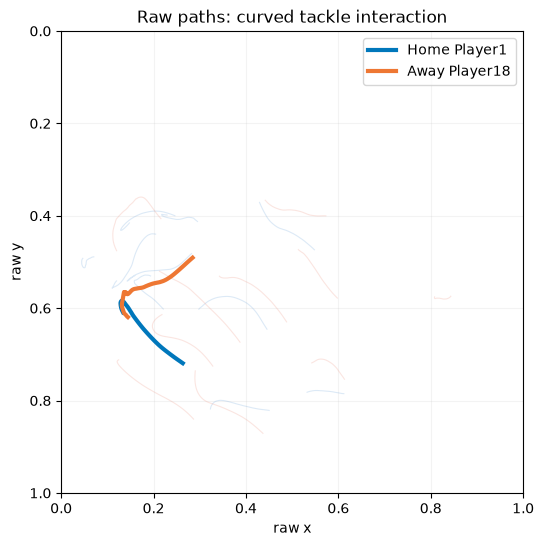

In [3]:
EXAMPLES=[
 {'name':'curved reversal','period':1,'start':590.0,'end':598.0,'def_team':'Home','defender':'2','att_team':'Away','attacker':'23'},
 {'name':'curved tackle interaction','period':1,'start':222.08,'end':227.08,'def_team':'Home','defender':'1','att_team':'Away','attacker':'18'}]
def window(team,s): return tracking[team][(tracking[team].Period==s['period'])&tracking[team]['Time [s]'].between(s['start'],s['end'])].copy()
def raw_views(s):
    d,a=window(s['def_team'],s),window(s['att_team'],s); idx=np.linspace(0,len(d)-1,9,dtype=int)
    fig,axes=plt.subplots(2,5,figsize=(17,7),constrained_layout=True); axes_flat=axes.flatten()
    for ax,i in zip(axes_flat,idx):
        dr,ar=d.iloc[i],a.iloc[i]
        for p in players[s['def_team']]: ax.scatter(dr[f"{s['def_team']}_{p}_x"],dr[f"{s['def_team']}_{p}_y"],c='#77aadd',s=14,alpha=.5)
        for p in players[s['att_team']]: ax.scatter(ar[f"{s['att_team']}_{p}_x"],ar[f"{s['att_team']}_{p}_y"],c='#ee9988',s=14,alpha=.5)
        ax.scatter(dr[f"{s['def_team']}_{s['defender']}_x"],dr[f"{s['def_team']}_{s['defender']}_y"],c='#0077bb',s=60,edgecolor='black',label='defender')
        ax.scatter(ar[f"{s['att_team']}_{s['attacker']}_x"],ar[f"{s['att_team']}_{s['attacker']}_y"],c='#ee7733',s=60,edgecolor='black',label='attacker')
        ax.scatter(dr[f"{s['def_team']}_ball_x"],dr[f"{s['def_team']}_ball_y"],c='black',marker='*',s=50)
        ax.set(xlim=(0,1),ylim=(1,0),aspect='equal',title=f"{dr['Time [s]']:.2f}s"); ax.grid(alpha=.15)
    axes_flat[-1].set_visible(False); fig.legend(*fig.axes[0].get_legend_handles_labels(),loc='upper center',ncol=2); fig.suptitle(f"Raw frames: {s['name']}",y=1.03); plt.show()
    fig,ax=plt.subplots(figsize=(9,6))
    for p in players[s['def_team']]: ax.plot(d[f"{s['def_team']}_{p}_x"],d[f"{s['def_team']}_{p}_y"],color='#77aadd',alpha=.25,lw=.8)
    for p in players[s['att_team']]: ax.plot(a[f"{s['att_team']}_{p}_x"],a[f"{s['att_team']}_{p}_y"],color='#ee9988',alpha=.25,lw=.8)
    ax.plot(d[f"{s['def_team']}_{s['defender']}_x"],d[f"{s['def_team']}_{s['defender']}_y"],color='#0077bb',lw=3,label=f"{s['def_team']} Player{s['defender']}")
    ax.plot(a[f"{s['att_team']}_{s['attacker']}_x"],a[f"{s['att_team']}_{s['attacker']}_y"],color='#ee7733',lw=3,label=f"{s['att_team']} Player{s['attacker']}")
    ax.set(xlim=(0,1),ylim=(1,0),aspect='equal',xlabel='raw x',ylabel='raw y',title=f"Raw paths: {s['name']}"); ax.grid(alpha=.15); ax.legend(); plt.show()
for s in EXAMPLES: raw_views(s)

## Physical units and transparent velocity calculation

The documented Metrica conversion is retained: `x_m = 105 x_raw`, `y_m = 68 y_raw`. Positions receive a centered rolling mean before velocity calculation. The primary window is 7 frames (0.28 s at 25 Hz); 5 and 9 frames provide sensitivity views. `min_periods` equals the complete window, so window edges and every rolling window containing a missing coordinate remain missing. No interpolation occurs. Velocity uses the same centered finite difference as Phase 1C: `(z[t+1] − z[t−1]) / (2/25)`.

The leave-one-out centroid is the framewise mean of other active defending outfield players, excluding the focal defender and manually documented Home goalkeeper Player11. Defender residual velocity is defender velocity minus centroid velocity component by component. This is not an additional structural reference or an assignment inference.

In [4]:
LENGTH=105.0; WIDTH=68.0; DT=1/25
def velocity(s): return (s.shift(-1)-s.shift(1))/(2*DT)
def coupling_frame(s,frames=7):
    d,a=window(s['def_team'],s),window(s['att_team'],s); g=d.merge(a[['Frame',f"{s['att_team']}_{s['attacker']}_x",f"{s['att_team']}_{s['attacker']}_y"]],on='Frame',validate='one_to_one')
    refs=[p for p in players[s['def_team']] if p not in {s['defender'],goalkeeper[s['def_team']]} and g[f"{s['def_team']}_{p}_x"].notna().any()]
    raw={'defender_x':g[f"{s['def_team']}_{s['defender']}_x"]*LENGTH,'defender_y':g[f"{s['def_team']}_{s['defender']}_y"]*WIDTH,'attacker_x':g[f"{s['att_team']}_{s['attacker']}_x"]*LENGTH,'attacker_y':g[f"{s['att_team']}_{s['attacker']}_y"]*WIDTH,'centroid_x':g[[f"{s['def_team']}_{p}_x" for p in refs]].mean(axis=1)*LENGTH,'centroid_y':g[[f"{s['def_team']}_{p}_y" for p in refs]].mean(axis=1)*WIDTH}
    out=pd.DataFrame({'Time [s]':g['Time [s]']})
    out['relative_x']=raw['attacker_x']-raw['defender_x']; out['relative_y']=raw['attacker_y']-raw['defender_y']
    for name,z in raw.items(): out[name]=z.rolling(frames,center=True,min_periods=frames).mean()
    for who in ['defender','attacker','centroid']:
        for axis in ['x','y']: out[f'{who}_v{axis}']=velocity(out[f'{who}_{axis}'])
    out['residual_vx']=out.defender_vx-out.centroid_vx; out['residual_vy']=out.defender_vy-out.centroid_vy
    return out,refs
for s in EXAMPLES:
    _,refs=coupling_frame(s,7); print(s['name'],'centroid contributors:',refs)

curved reversal centroid contributors: ['1', '3', '4', '5', '6', '7', '8', '9', '10']
curved tackle interaction centroid contributors: ['2', '3', '4', '5', '6', '7', '8', '9', '10']


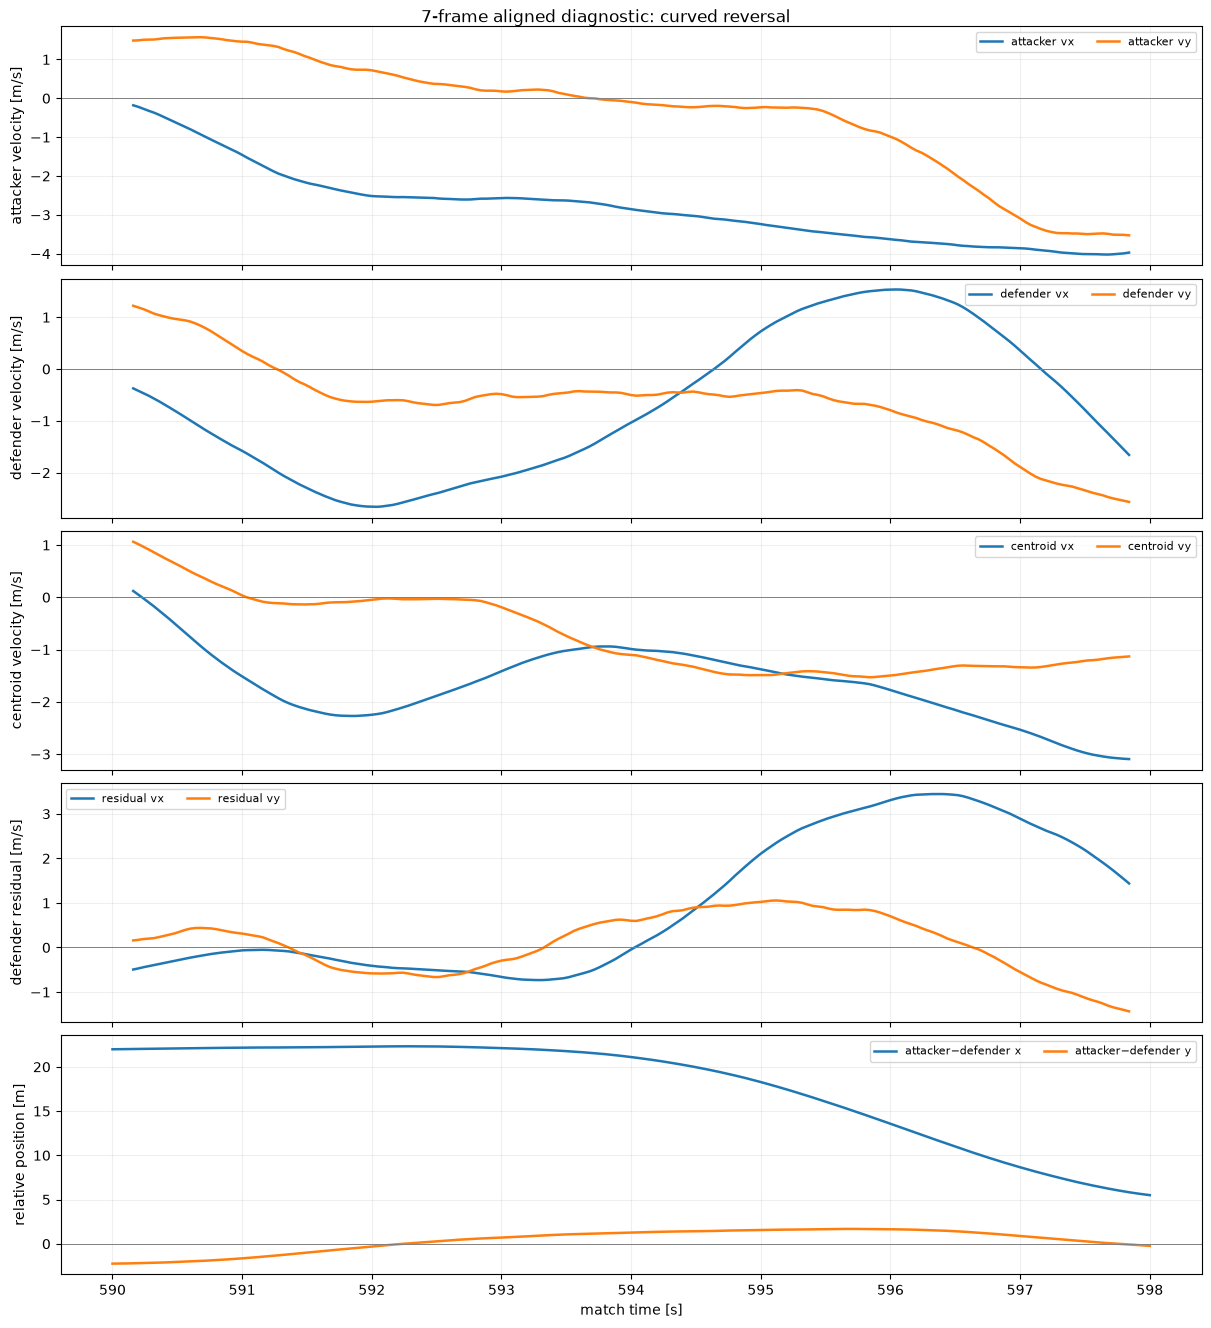

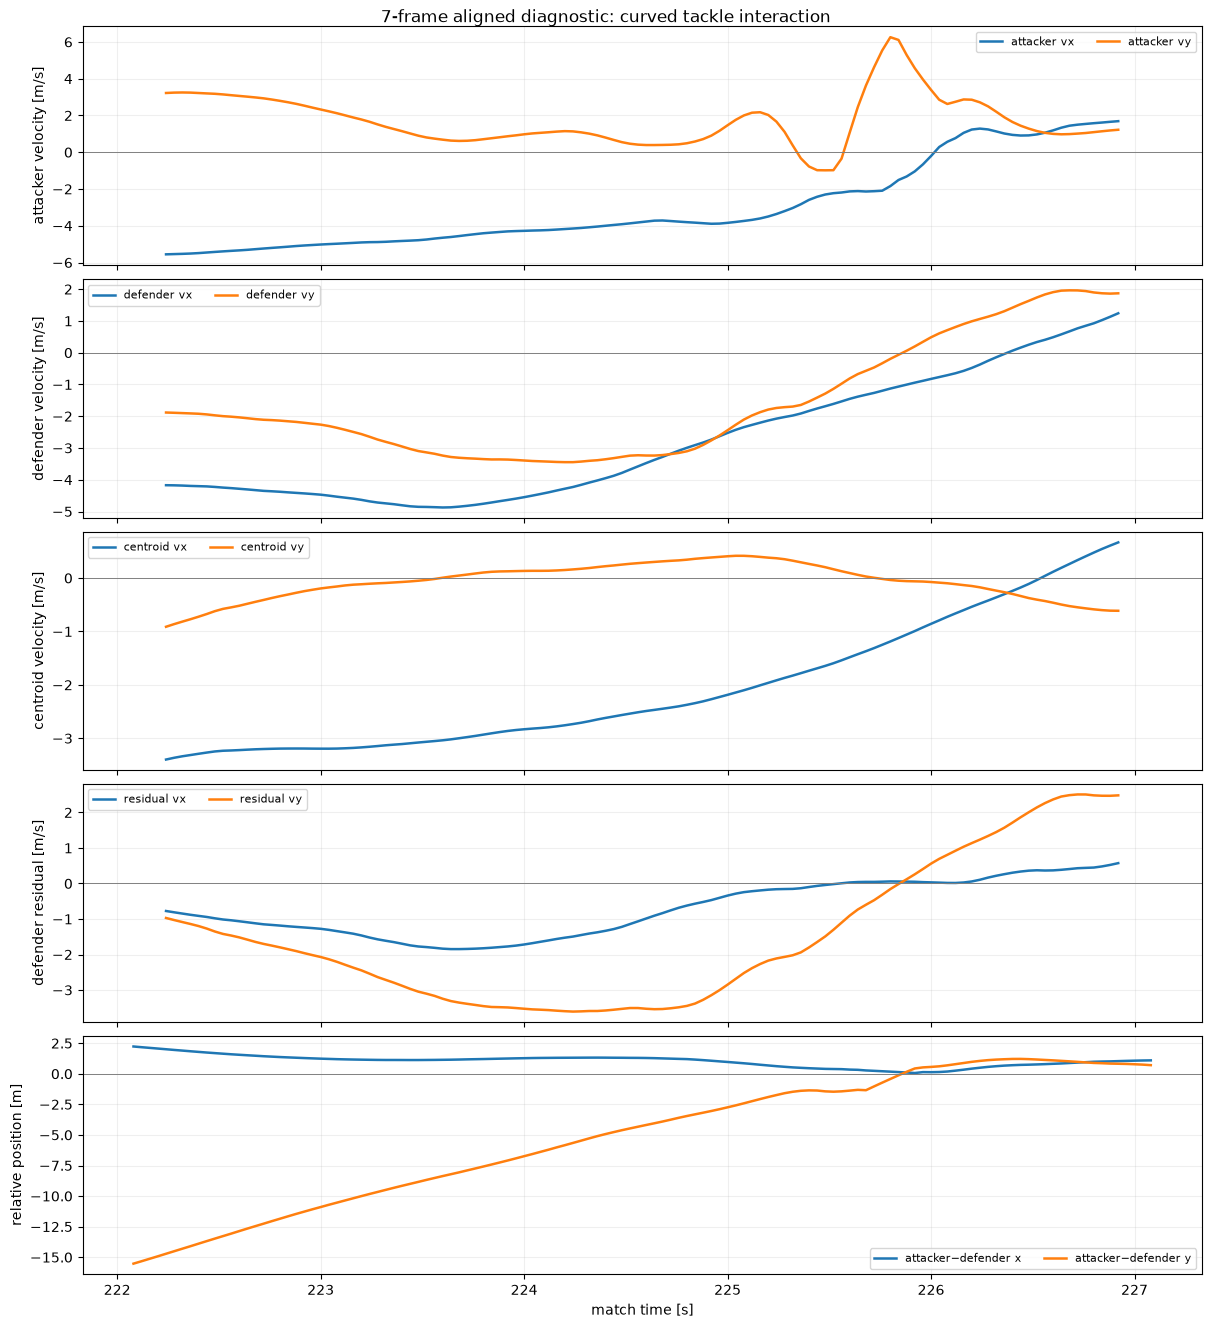

In [5]:
def aligned_plot(s):
    k,_=coupling_frame(s,7); t=k['Time [s]']
    panels=[(['attacker_vx','attacker_vy'],['attacker vx','attacker vy'],'attacker velocity [m/s]'),(['defender_vx','defender_vy'],['defender vx','defender vy'],'defender velocity [m/s]'),(['centroid_vx','centroid_vy'],['centroid vx','centroid vy'],'centroid velocity [m/s]'),(['residual_vx','residual_vy'],['residual vx','residual vy'],'defender residual [m/s]'),(['relative_x','relative_y'],['attacker−defender x','attacker−defender y'],'relative position [m]')]
    fig,axes=plt.subplots(5,1,figsize=(12,13),sharex=True,constrained_layout=True)
    for ax,(cols,labels,ylabel) in zip(axes,panels):
        for c,label in zip(cols,labels): ax.plot(t,k[c],label=label,lw=1.8)
        ax.axhline(0,color='grey',lw=.7); ax.grid(alpha=.2); ax.set_ylabel(ylabel); ax.legend(ncol=2,fontsize=8)
    axes[-1].set_xlabel('match time [s]'); fig.suptitle(f"7-frame aligned diagnostic: {s['name']}",y=1.01); plt.show()
for s in EXAMPLES: aligned_plot(s)

## 5/7/9-frame sensitivity

The plots below compare the visible timing and sign of attacker and defender-residual component changes under the three predeclared windows. They are visual sensitivity checks only; no similarity, lag, or fit statistic is calculated.

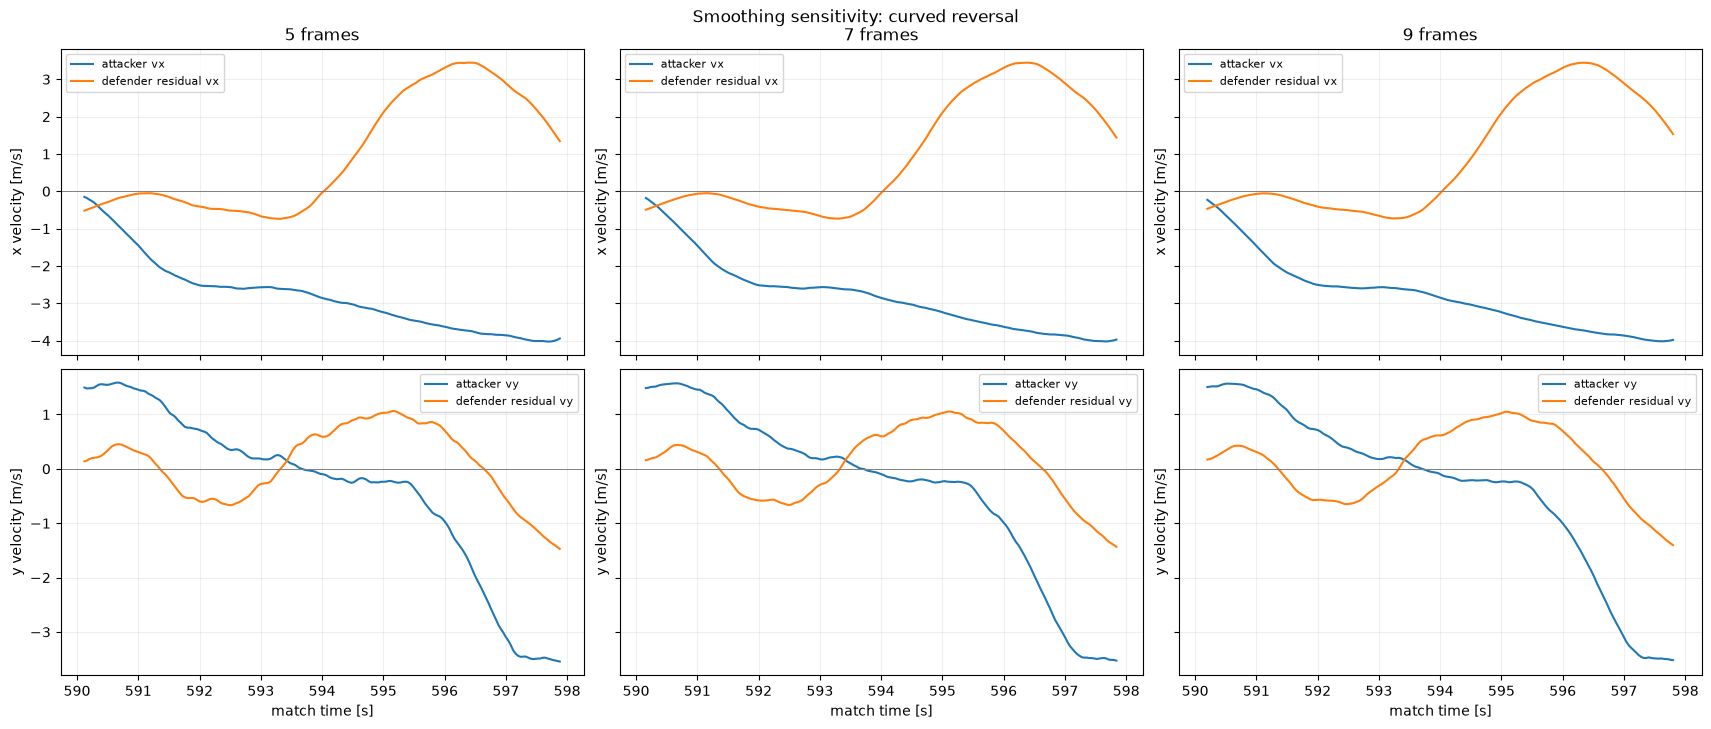

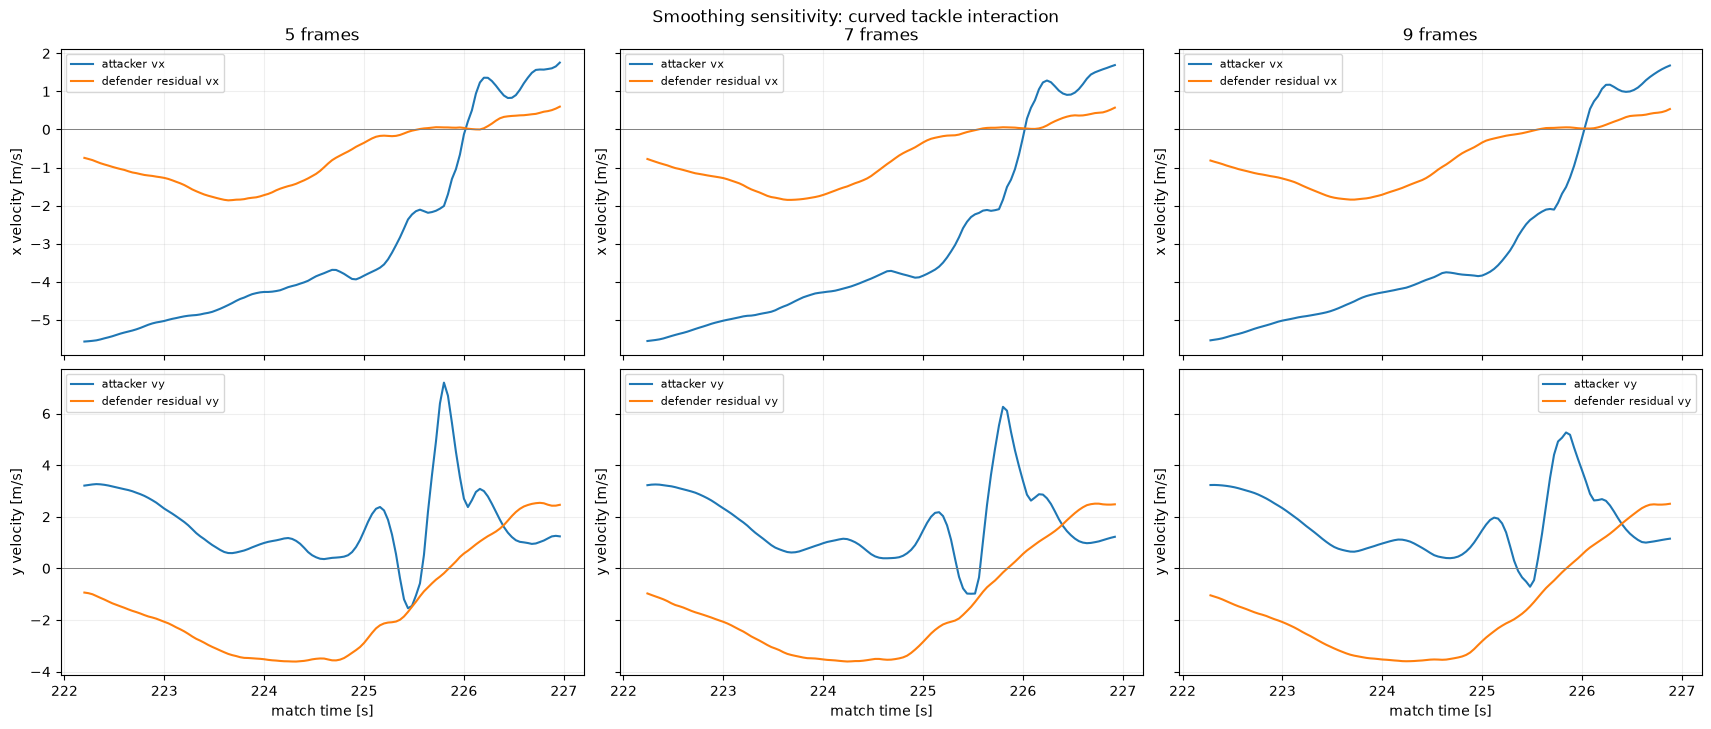

In [6]:
def sensitivity_plot(s):
    fig,axes=plt.subplots(2,3,figsize=(17,7),sharex=True,sharey='row',constrained_layout=True)
    for col,frames in enumerate([5,7,9]):
        k,_=coupling_frame(s,frames); t=k['Time [s]']
        axes[0,col].plot(t,k.attacker_vx,label='attacker vx'); axes[0,col].plot(t,k.residual_vx,label='defender residual vx'); axes[0,col].set_title(f'{frames} frames'); axes[0,col].set_ylabel('x velocity [m/s]')
        axes[1,col].plot(t,k.attacker_vy,label='attacker vy'); axes[1,col].plot(t,k.residual_vy,label='defender residual vy'); axes[1,col].set_ylabel('y velocity [m/s]'); axes[1,col].set_xlabel('match time [s]')
        for ax in axes[:,col]: ax.axhline(0,color='grey',lw=.7); ax.grid(alpha=.2); ax.legend(fontsize=8)
    fig.suptitle(f"Smoothing sensitivity: {s['name']}",y=1.02); plt.show()
for s in EXAMPLES: sensitivity_plot(s)

## Interpretation and stopping point

These plots compare visible changes rather than estimating coupling. The two fixed examples give mixed evidence. In the 590–598 s curved reversal, the raw paths look linked, but attacker x velocity becomes progressively more negative while defender-residual x turns strongly positive after roughly 594 s. The y components also do not show one clean corresponding adjustment. This example therefore does **not** clearly support opponent-movement coupling after collective translation is removed. Its changing relative x/y position also confirms that the earlier constant-offset formulation and the raw visual impression are not equivalent.

The 222.08–227.08 s tackle interaction provides limited support: attacker x changes from strongly negative to positive and defender-residual x makes the same broad sign transition; defender-residual y also changes from negative to positive around the attacker's sharper y-direction disturbance. The correspondence is broad rather than exact, and the interaction is confounded by closing, contact, ball response, and tackle mechanics. It cannot establish sustained following or assignment.

The broad supporting and non-supporting patterns remain visible with 5-, 7-, and 9-frame rolling means. That is a visual sensitivity observation only, not a similarity or lag estimate.

Plausible alternatives include simultaneous response to the ball, space or passing lanes; line maintenance; shared reaction to a third player or phase change; tackle mechanics; coordinated team rotation not represented by a centroid translation; and coincidental timing. The leave-one-out centroid removes only translation and cannot represent rotation, compression, line-specific behavior, or tactical role.

Fixed attacker-relative position and movement coupling describe different possible aspects. Constant relative position concerns maintenance of an offset. Coupling concerns whether movement changes correspond, even while the offset changes. Neither proves assignment, intent, tracking, or psychological allocation.

This notebook stops after the fixed-example visual diagnostic. It does not proceed to relational weights, a general relational model, ambiguity or reallocation metrics, states, HMMs, classifiers, or machine learning.